# Feature Engineering

## Objective

To analyze the importance and quality of input features by identifying low-variance features, examining feature correlations, and preparing the final feature set for machine learning model development.

In [1]:
import pandas as pd
import numpy as np

from sklearn.feature_selection import VarianceThreshold

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
column_names = [
    "unit_number",
    "time_in_cycles",
    "operational_setting_1",
    "operational_setting_2",
    "operational_setting_3"
]

for i in range(1,22):
    column_names.append(f"sensor_{i}")

train_df = pd.read_csv(
    "../data/raw/train_FD001.txt",
    sep=r"\s+",
    header=None,
    names=column_names
)

In [3]:
max_cycles = train_df.groupby("unit_number")["time_in_cycles"].max()

train_df = train_df.merge(
    max_cycles.rename("max_cycle"),
    on="unit_number"
)

train_df["RUL"] = (
    train_df["max_cycle"] -
    train_df["time_in_cycles"]
)

train_df.drop(columns=["max_cycle"], inplace=True)

In [4]:
X = train_df.drop(
    columns=[
        "unit_number",
        "RUL"
    ]
)

y = train_df["RUL"]

In [5]:
variance = X.var()

variance.sort_values()

operational_setting_3    0.000000e+00
sensor_1                 0.000000e+00
sensor_10                0.000000e+00
sensor_19                0.000000e+00
sensor_18                0.000000e+00
sensor_16                1.203765e-35
sensor_5                 2.840037e-29
operational_setting_2    8.588541e-08
sensor_6                 1.929279e-06
operational_setting_1    4.784340e-06
sensor_15                1.406628e-03
sensor_8                 5.038938e-03
sensor_13                5.172330e-03
sensor_21                1.171825e-02
sensor_20                3.266927e-02
sensor_11                7.133568e-02
sensor_2                 2.500533e-01
sensor_12                5.439850e-01
sensor_7                 7.833883e-01
sensor_17                2.398667e+00
sensor_3                 3.759099e+01
sensor_4                 8.101089e+01
sensor_14                3.639005e+02
sensor_9                 4.876536e+02
time_in_cycles           4.744591e+03
dtype: float64

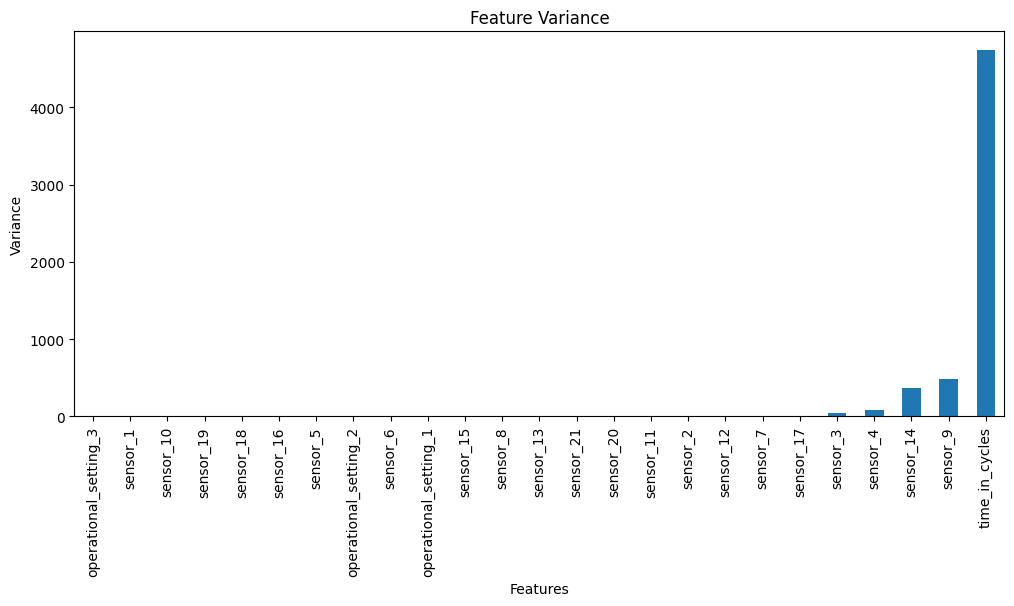

In [6]:
plt.figure(figsize=(12,5))

variance.sort_values().plot(kind="bar")

plt.title("Feature Variance")

plt.xlabel("Features")

plt.ylabel("Variance")

plt.show()

Features with extremely low variance provide limited information and may not contribute significantly to model performance.

In [7]:
selector = VarianceThreshold(threshold=0.01)

selector.fit(X)

selected_features = X.columns[selector.get_support()]

print("Selected Features:")
print(selected_features)

Selected Features:
Index(['time_in_cycles', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7',
       'sensor_9', 'sensor_11', 'sensor_12', 'sensor_14', 'sensor_17',
       'sensor_20', 'sensor_21'],
      dtype='object')


In [8]:
X_selected = X[selected_features]

print("Original Shape :", X.shape)
print("Selected Shape :", X_selected.shape)

Original Shape : (20631, 25)
Selected Shape : (20631, 12)


In [9]:
correlation = train_df.corr(numeric_only=True)["RUL"].sort_values()

correlation

time_in_cycles          -0.736241
sensor_11               -0.696228
sensor_4                -0.678948
sensor_15               -0.642667
sensor_2                -0.606484
sensor_17               -0.606154
sensor_3                -0.584520
sensor_8                -0.563968
sensor_13               -0.562569
sensor_9                -0.390102
sensor_14               -0.306769
sensor_6                -0.128348
operational_setting_1   -0.003198
operational_setting_2   -0.001948
unit_number              0.078753
sensor_20                0.629428
sensor_21                0.635662
sensor_7                 0.657223
sensor_12                0.671983
RUL                      1.000000
operational_setting_3         NaN
sensor_1                      NaN
sensor_5                      NaN
sensor_10                     NaN
sensor_16                     NaN
sensor_18                     NaN
sensor_19                     NaN
Name: RUL, dtype: float64

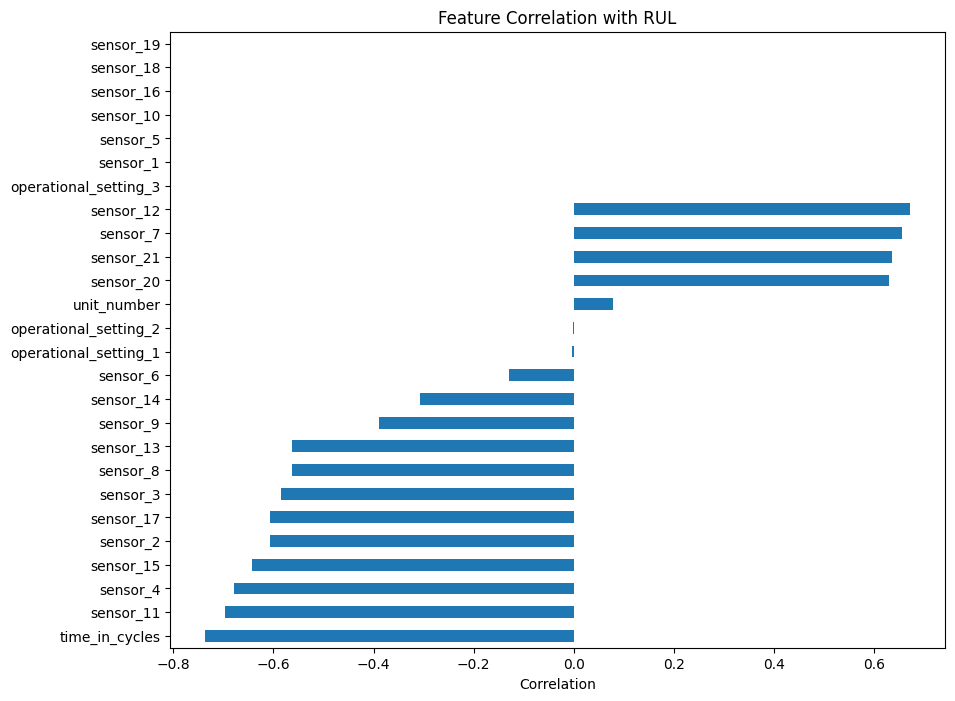

In [10]:
plt.figure(figsize=(10,8))

correlation.drop("RUL").plot(kind="barh")

plt.title("Feature Correlation with RUL")

plt.xlabel("Correlation")

plt.show()

In [11]:
high_corr = correlation[
    abs(correlation) > 0.30
]

print(high_corr)

time_in_cycles   -0.736241
sensor_11        -0.696228
sensor_4         -0.678948
sensor_15        -0.642667
sensor_2         -0.606484
sensor_17        -0.606154
sensor_3         -0.584520
sensor_8         -0.563968
sensor_13        -0.562569
sensor_9         -0.390102
sensor_14        -0.306769
sensor_20         0.629428
sensor_21         0.635662
sensor_7          0.657223
sensor_12         0.671983
RUL               1.000000
Name: RUL, dtype: float64


In [12]:
final_df = train_df[
    list(selected_features) + ["RUL"]
]

final_df.head()

,time_in_cycles,sensor_2,sensor_3,sensor_4,sensor_7,sensor_9,sensor_11,sensor_12,sensor_14,sensor_17,sensor_20,sensor_21,RUL
0,1,641.82,1589.70,1400.60,554.36,9046.19,47.47,521.66,8138.62,392,39.06,23.4190,191
1,2,642.15,1591.82,1403.14,553.75,9044.07,47.49,522.28,8131.49,392,39.00,23.4236,190
2,3,642.35,1587.99,1404.20,554.26,9052.94,47.27,522.42,8133.23,390,38.95,23.3442,189
3,4,642.35,1582.79,1401.87,554.45,9049.48,47.13,522.86,8133.83,392,38.88,23.3739,188
4,5,642.37,1582.85,1406.22,554.00,9055.15,47.28,522.19,8133.80,393,38.90,23.4044,187


## Conclusion

- Feature variance analysis identified informative and low-variance features.
- Low-variance features were removed using VarianceThreshold.
- Correlation analysis highlighted features most strongly associated with Remaining Useful Life (RUL).
- The refined feature set is ready for machine learning model development.